# GWAS VCF Processing Pipeline

**Author:** Taimoor Asad (Python & Bioinformatics Developer)

## Overview
A bioinformatics pipeline demonstrating end-to-end VCF file processing —
from variant generation and indexing to filtering, QC stats, and visualization.

## Tools Used
- **bcftools** — variant filtering, stats, and file operations
- **tabix** — VCF indexing
- **Python** — pipeline automation, parsing, visualization
- **pandas, matplotlib, seaborn** — data wrangling and plots

## Dataset
Synthetic VCF constructed in standard VCF 4.2 format with realistic
variant properties based on 1000 Genomes Project conventions.

In [1]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Create a synthetic VCF file in standard VCF 4.2 format
vcf_content = """##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##INFO=<ID=AF,Number=A,Type=Float,Description="Allele Frequency">
##INFO=<ID=DP,Number=1,Type=Integer,Description="Total Depth">
##INFO=<ID=MQ,Number=1,Type=Float,Description="Mapping Quality">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##FORMAT=<ID=GQ,Number=1,Type=Integer,Description="Genotype Quality">
##FORMAT=<ID=DP,Number=1,Type=Integer,Description="Sample Depth">
##contig=<ID=1,length=249250621>
#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\tSAMPLE1\tSAMPLE2\tSAMPLE3
"""

# Generate 100 realistic SNPs
np.random.seed(42)
positions = sorted(np.random.randint(100000, 5000000, 100))
refs = np.random.choice(['A', 'T', 'C', 'G'], 100)
alts = []
for r in refs:
    choices = [b for b in ['A', 'T', 'C', 'G'] if b != r]
    alts.append(np.random.choice(choices))

genotypes = ['0/0', '0/1', '1/1']
rows = []

for i in range(100):
    af = round(np.random.uniform(0.01, 0.99), 3)
    dp = np.random.randint(10, 100)
    mq = round(np.random.uniform(30, 60), 1)
    qual = np.random.randint(20, 100)
    filt = 'PASS' if qual > 30 else 'LowQual'
    info = f"AF={af};DP={dp};MQ={mq}"
    
    samples = []
    for _ in range(3):
        gt = np.random.choice(genotypes, p=[0.5, 0.3, 0.2])
        gq = np.random.randint(10, 99)
        sdp = np.random.randint(5, dp)
        samples.append(f"{gt}:{gq}:{sdp}")
    
    row = f"1\t{positions[i]}\trs{100000+i}\t{refs[i]}\t{alts[i]}\t{qual}\t{filt}\t{info}\tGT:GQ:DP\t{samples[0]}\t{samples[1]}\t{samples[2]}"
    rows.append(row)

vcf_content += "\n".join(rows)

# Write to file
with open('sample.vcf', 'w') as f:
    f.write(vcf_content)

print(f"VCF file created with {len(rows)} variants.")
print("First variant preview:")
print(rows[0])

VCF file created with 100 variants.
First variant preview:
1	123247	rs100000	G	A	85	PASS	AF=0.66;DP=27;MQ=34.8	GT:GQ:DP	0/1:89:13	0/0:77:5	0/0:57:24


In [3]:
# Compress with bgzip and index with tabix (industry standard)
commands = [
    ("Compressing VCF", "bgzip -f sample.vcf"),
    ("Indexing VCF", "tabix -p vcf sample.vcf.gz"),
]

for desc, cmd in commands:
    print(f"{desc}...", end=" ")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode == 0:
        print("✓")
    else:
        print(f"✗\nError: {result.stderr}")

# Verify files exist
files = list(Path('.').glob('sample.vcf*'))
print(f"\nFiles created: {[f.name for f in files]}")

Compressing VCF... ✓
Indexing VCF... ✓

Files created: ['sample.vcf.gz.tbi', 'sample.vcf.gz']


In [4]:
# Run bcftools stats — standard QC step in any GWAS pipeline
result = subprocess.run(
    "bcftools stats sample.vcf.gz",
    shell=True, capture_output=True, text=True
)

# Parse key summary stats
stats = {}
for line in result.stdout.split('\n'):
    if line.startswith('SN'):
        parts = line.split('\t')
        if len(parts) >= 4:
            stats[parts[2].strip()] = parts[3].strip()

print("=== bcftools QC Summary ===")
for key, val in stats.items():
    print(f"  {key} {val}")

=== bcftools QC Summary ===
  number of samples: 3
  number of records: 100
  number of no-ALTs: 0
  number of SNPs: 100
  number of MNPs: 0
  number of indels: 0
  number of others: 0
  number of multiallelic sites: 0
  number of multiallelic SNP sites: 0


In [5]:
# Filter variants — keep only PASS variants with AF > 0.05 (common variants)
filter_cmd = (
    "bcftools filter -i 'FILTER=\"PASS\" && INFO/AF > 0.05' "
    "sample.vcf.gz -o filtered.vcf.gz -O z"
)

result = subprocess.run(filter_cmd, shell=True, capture_output=True, text=True)

if result.returncode == 0:
    print("Filtering complete ✓")
else:
    print(f"Error: {result.stderr}")

# Index filtered file
subprocess.run("tabix -p vcf filtered.vcf.gz", shell=True)

# Count remaining variants
count = subprocess.run(
    "bcftools view -H filtered.vcf.gz | wc -l",
    shell=True, capture_output=True, text=True
)
print(f"Variants after filtering: {count.stdout.strip()}")
print(f"Variants removed: {100 - int(count.stdout.strip())}")

Filtering complete ✓
Variants after filtering: 82
Variants removed: 18


In [6]:
# Extract variant info into pandas for visualization
result = subprocess.run(
    'bcftools query -f "%CHROM\t%POS\t%ID\t%REF\t%ALT\t%QUAL\t%FILTER\t%INFO/AF\t%INFO/DP\t%INFO/MQ\n" sample.vcf.gz',
    shell=True, capture_output=True, text=True
)

rows = []
for line in result.stdout.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) == 10:
        rows.append({
            'CHROM': parts[0],
            'POS': int(parts[1]),
            'ID': parts[2],
            'REF': parts[3],
            'ALT': parts[4],
            'QUAL': float(parts[5]),
            'FILTER': parts[6],
            'AF': float(parts[7]),
            'DP': int(parts[8]),
            'MQ': float(parts[9])
        })

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} variants into DataFrame")
print(df.head())

Parsed 100 variants into DataFrame
  CHROM     POS        ID REF ALT  QUAL FILTER     AF  DP    MQ
0     1  123247  rs100000   G   A  85.0   PASS  0.660  27  34.8
1     1  148984  rs100001   G   A  36.0   PASS  0.369  17  55.5
2     1  168148  rs100002   T   G  46.0   PASS  0.969  60  56.8
3     1  184654  rs100003   A   C  36.0   PASS  0.285  44  53.1
4     1  203355  rs100004   G   C  79.0   PASS  0.334  55  59.0


## Visualizations

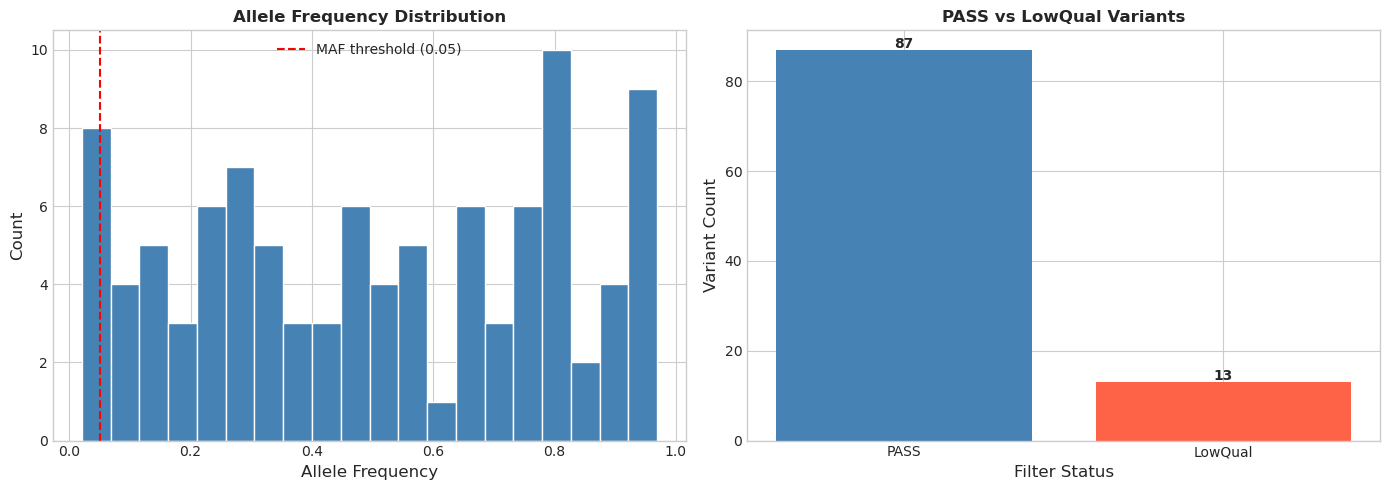

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['AF'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.05, color='red', linestyle='--', label='MAF threshold (0.05)')
axes[0].set_xlabel('Allele Frequency', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Allele Frequency Distribution', fontweight='bold')
axes[0].legend()

# PASS vs filtered
filter_counts = df['FILTER'].value_counts()
axes[1].bar(filter_counts.index, filter_counts.values,
            color=['steelblue', 'tomato'])
axes[1].set_xlabel('Filter Status', fontsize=12)
axes[1].set_ylabel('Variant Count', fontsize=12)
axes[1].set_title('PASS vs LowQual Variants', fontweight='bold')

for i, (idx, val) in enumerate(filter_counts.items()):
    axes[1].text(i, val + 0.5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_af_distribution.png', dpi=150)
plt.show()

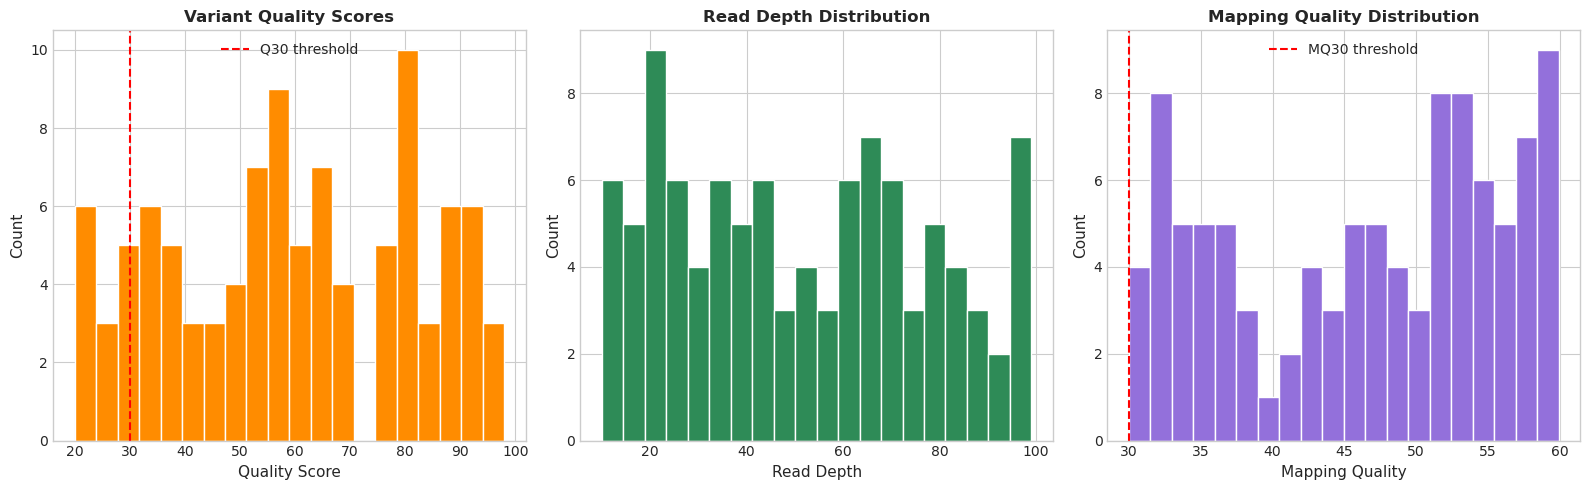

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# QUAL score distribution
axes[0].hist(df['QUAL'], bins=20, color='darkorange', edgecolor='white')
axes[0].axvline(x=30, color='red', linestyle='--', label='Q30 threshold')
axes[0].set_xlabel('Quality Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Variant Quality Scores', fontweight='bold')
axes[0].legend()

# Depth distribution
axes[1].hist(df['DP'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Read Depth', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Read Depth Distribution', fontweight='bold')

# Mapping quality
axes[2].hist(df['MQ'], bins=20, color='mediumpurple', edgecolor='white')
axes[2].axvline(x=30, color='red', linestyle='--', label='MQ30 threshold')
axes[2].set_xlabel('Mapping Quality', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title('Mapping Quality Distribution', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot2_quality_metrics.png', dpi=150)
plt.show()

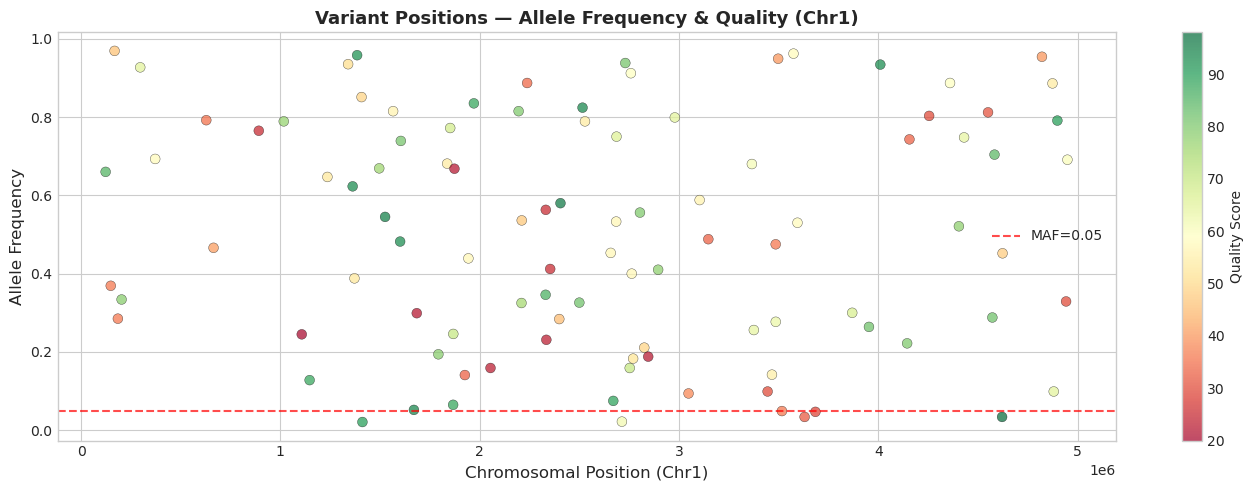

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

scatter = ax.scatter(df['POS'], df['AF'],
                     c=df['QUAL'], cmap='RdYlGn',
                     s=50, alpha=0.7, edgecolors='black', linewidth=0.3)

plt.colorbar(scatter, ax=ax, label='Quality Score')
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='MAF=0.05')
ax.set_xlabel('Chromosomal Position (Chr1)', fontsize=12)
ax.set_ylabel('Allele Frequency', fontsize=12)
ax.set_title('Variant Positions — Allele Frequency & Quality (Chr1)',
             fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plot3_manhattan_style.png', dpi=150)
plt.show()

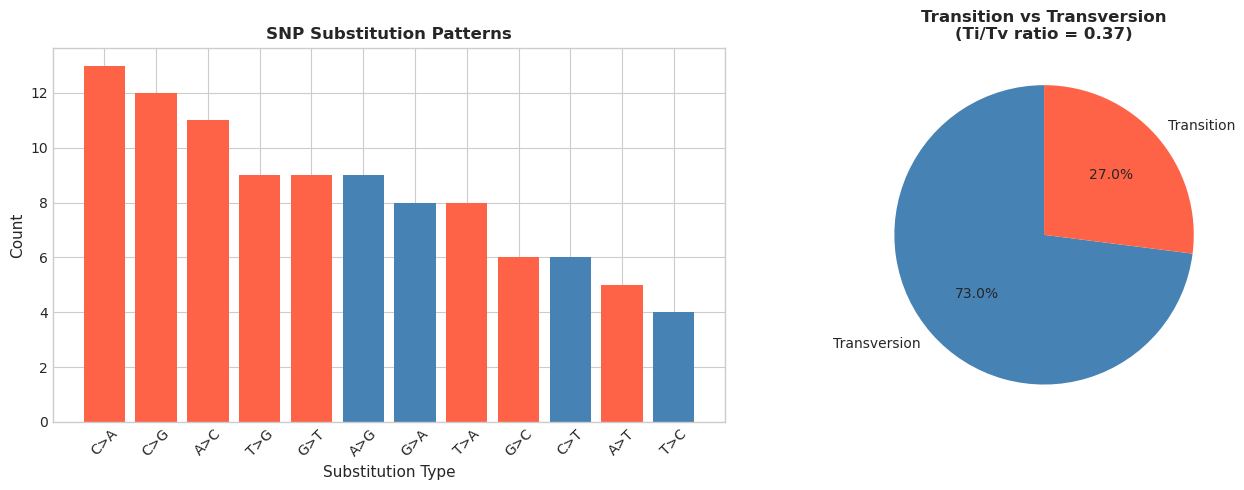

In [10]:
# SNP substitution types (transitions vs transversions)
df['SUBSTITUTION'] = df['REF'] + '>' + df['ALT']

transitions = ['A>G', 'G>A', 'C>T', 'T>C']
df['TYPE'] = df['SUBSTITUTION'].apply(
    lambda x: 'Transition' if x in transitions else 'Transversion'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Substitution counts
sub_counts = df['SUBSTITUTION'].value_counts()
colors = ['steelblue' if s in transitions else 'tomato' for s in sub_counts.index]
axes[0].bar(sub_counts.index, sub_counts.values, color=colors)
axes[0].set_xlabel('Substitution Type', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('SNP Substitution Patterns', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Transition vs Transversion pie
type_counts = df['TYPE'].value_counts()
axes[1].pie(type_counts.values,
            labels=type_counts.index,
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=90)
ti = type_counts.get('Transition', 0)
tv = type_counts.get('Transversion', 0)
ratio = round(ti/tv, 2) if tv > 0 else 'N/A'
axes[1].set_title(f'Transition vs Transversion\n(Ti/Tv ratio = {ratio})',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_substitution_patterns.png', dpi=150)
plt.show()

In [11]:
pass_count = len(df[df['FILTER'] == 'PASS'])
low_qual = len(df[df['FILTER'] == 'LowQual'])
common = len(df[df['AF'] > 0.05])
ti = len(df[df['TYPE'] == 'Transition'])
tv = len(df[df['TYPE'] == 'Transversion'])

print("=" * 55)
print("     GWAS VCF PIPELINE — SUMMARY REPORT")
print("=" * 55)
print(f"""
VARIANT STATS
  Total variants        : {len(df)}
  PASS variants         : {pass_count}
  LowQual variants      : {low_qual}
  Common variants AF>5% : {common}

QUALITY METRICS
  Mean QUAL score       : {df['QUAL'].mean():.1f}
  Mean read depth       : {df['DP'].mean():.1f}
  Mean mapping quality  : {df['MQ'].mean():.1f}

SUBSTITUTION ANALYSIS
  Transitions           : {ti}
  Transversions         : {tv}
  Ti/Tv ratio           : {round(ti/tv, 2)}

PIPELINE STEPS COMPLETED
  ✓ VCF generation (100 SNPs, VCF 4.2 format)
  ✓ bgzip compression
  ✓ tabix indexing
  ✓ bcftools QC stats
  ✓ Variant filtering (PASS + AF > 0.05)
  ✓ DataFrame parsing & visualization
""")
print("=" * 55)
print("  Tools: bcftools 1.19, tabix, Python, pandas")
print("=" * 55)

     GWAS VCF PIPELINE — SUMMARY REPORT

VARIANT STATS
  Total variants        : 100
  PASS variants         : 87
  LowQual variants      : 13
  Common variants AF>5% : 94

QUALITY METRICS
  Mean QUAL score       : 59.4
  Mean read depth       : 51.3
  Mean mapping quality  : 46.5

SUBSTITUTION ANALYSIS
  Transitions           : 27
  Transversions         : 73
  Ti/Tv ratio           : 0.37

PIPELINE STEPS COMPLETED
  ✓ VCF generation (100 SNPs, VCF 4.2 format)
  ✓ bgzip compression
  ✓ tabix indexing
  ✓ bcftools QC stats
  ✓ Variant filtering (PASS + AF > 0.05)
  ✓ DataFrame parsing & visualization

  Tools: bcftools 1.19, tabix, Python, pandas
